run:1, b: -0.8967166979362103
run:2, b: -0.9152908067542215
run:3, b: -0.8706848030018752
run:4, b: -0.8619136960600378
run:5, b: -0.9139774859287051
run:6, b: -0.8309568480300173
run:7, b: -0.8243433395872418
run:8, b: -0.8673076923076926
run:9, b: -0.8646810506566585
run:10, b: -0.8926829268292681
run:11, b: -0.8828799249530953


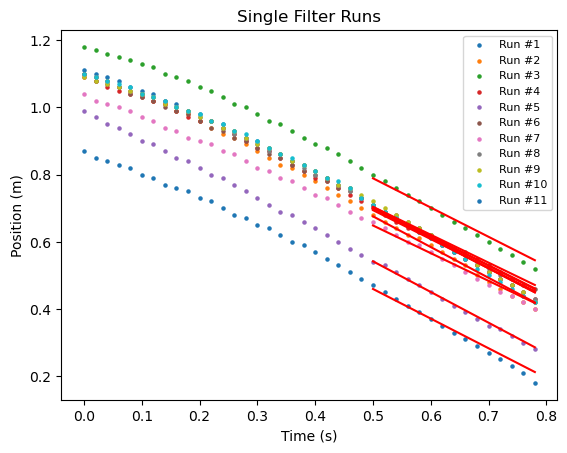

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

single_filter_df = pd.read_csv('data_with_terminal_speed.csv', encoding='unicode_escape')

# Function for cleaning noisy data
def mainCleanData(data_df):
    time_lst = []
    pos_lst = []
    empty_df = pd.DataFrame()
    positions_df = data_df.iloc[:,11:] #all position columns in the data_df, 11 cause we had 11 runs
    num_columns = len(positions_df.columns) #number of columns
    for column in range(num_columns): 
        position = positions_df.iloc[:,column] #individual column
        first_index = minVal(position)
        first_truncated_df = data_df.iloc[:first_index-6, [column,column+11]]
        
        second_index = cutStart(first_truncated_df)
        second_truncated_df = (first_truncated_df.iloc[second_index:, :]).reset_index(drop=True)
        
        #second_truncated_df.plot(kind="line", x = second_truncated_df.columns[0], y = second_truncated_df.columns[1])#graphs for each run 
        time_lst.append(second_truncated_df.iloc[:,0])
        pos_lst.append(second_truncated_df.iloc[:,1])
    clean_lst = time_lst + pos_lst
    empty_df = pd.concat(clean_lst, axis=1)
    return empty_df

#Function that finds the minimum value in position and returns its index
def minVal(position):
    index = 0
    min = position.iat[0]
    for i in range(1, len(position)-1):
        curr = position.iat[i]
        if curr < min and curr:
            min = curr
            index = i
    
    return index

#Function that gives index to make cut at the start
def cutStart(first_truncated_df):
    for i in range(len(first_truncated_df)-7):#checked with 7 values,it should be big enough to check the start of the descent
        temp_df = first_truncated_df.iloc[i:i+7, [1]]
        flag = 0
        
        for j in range(len(temp_df)-1):#checks if the next 7 values go down(reverse list type of problem)
            if temp_df.iat[j, 0] <= temp_df.iat[j+1, 0]:
                flag = 1
        if not flag:
            return i
#makes the regression line
def regressionFit(x_coor, y_coor, i,count,clean_df):
    b, a = np.polyfit(x_coor, y_coor, deg = 1) #b is a slope, a is y intercept
    print(f"run:{i+1}, b: {b}")
    count += b
    xseq = np.linspace(0.5,clean_df.iloc[-1, i])
    reg_line = plt.plot(xseq, b *xseq+a, c ='red')
    return reg_line,count
#makes the scatter plot 
def scatter(clean_df):
    #Plotting data as scatter points with matplot
    count = 0
    clean_df = clean_df.dropna()
    for i in range((int(len(clean_df.columns)/2))):
        xpoints = clean_df.iloc[:, i].to_numpy()
        ypoints =clean_df.iloc[:, (i+int(len(clean_df.columns)/2))].to_numpy()
        plt.scatter(xpoints, ypoints, s  = 5, label=f'Run #{i+1}')
        regressionFit(xpoints, ypoints, i,count,clean_df)
    plt.legend(fontsize=8)
    plt.title('Single Filter Runs')
    plt.xlabel('Time (s)')
    plt.ylabel('Position (m)')
    #rint(count) 

#full function
def main(): 
    # Formatting columns 
    data1_df = single_filter_df.iloc[:, 0::4]
    data2_df = single_filter_df.iloc[:, 1::4]
    data_df = pd.concat([data1_df,data2_df], axis = 1)
    data_df = data_df.fillna(0) #dropping NA values

    #cleaning main data
    clean_df = mainCleanData(data_df)

    #make sure the increments are changed from 0 by 0.02
    for i in range(11): #11 columns for time
        count = 0
        for j in range(len(clean_df.iloc[:,i])):
            clean_df.iat[j,i] = round(count,3)
            count += 0.02

    clean_df.to_csv('clean_data_single_filter.csv',index=False)
    scatter(clean_df)

main()
    

















 




